# 02 — Bandit simulation

Stage 3: compare the deterministic baseline against the adaptive policies
(Thompson, UCB1, Nilos-UCB, LinUCB, neural) on the seeded oracle environment
with **delayed feedback**. We plot cumulative reward and regret, and the arm
distribution. The full 20k-step run + MLflow logging lives in
`aep bandits report`; here we use a shorter run for fast, visual intuition.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from aep.bandits.environment import build_environment
from aep.bandits.runner import POLICY_BUILDERS
from aep.bandits.simulator import run_policy

env = build_environment(n_steps=8000)
results = {}
for name, (builder, _params) in POLICY_BUILDERS.items():
    policy = builder(np.random.default_rng(123), env.n_arms, env.dim)
    results[name] = run_policy(policy, env, delayed=True)
{n: round(r.conversion_rate, 4) for n, r in results.items()}

{'random': 0.0595,
 'greedy_baseline': 0.0867,
 'thompson': 0.1101,
 'ucb1': 0.0939,
 'nilos_ucb': 0.1001,
 'linucb': 0.1288,
 'neural': 0.1075}

## Cumulative reward and regret

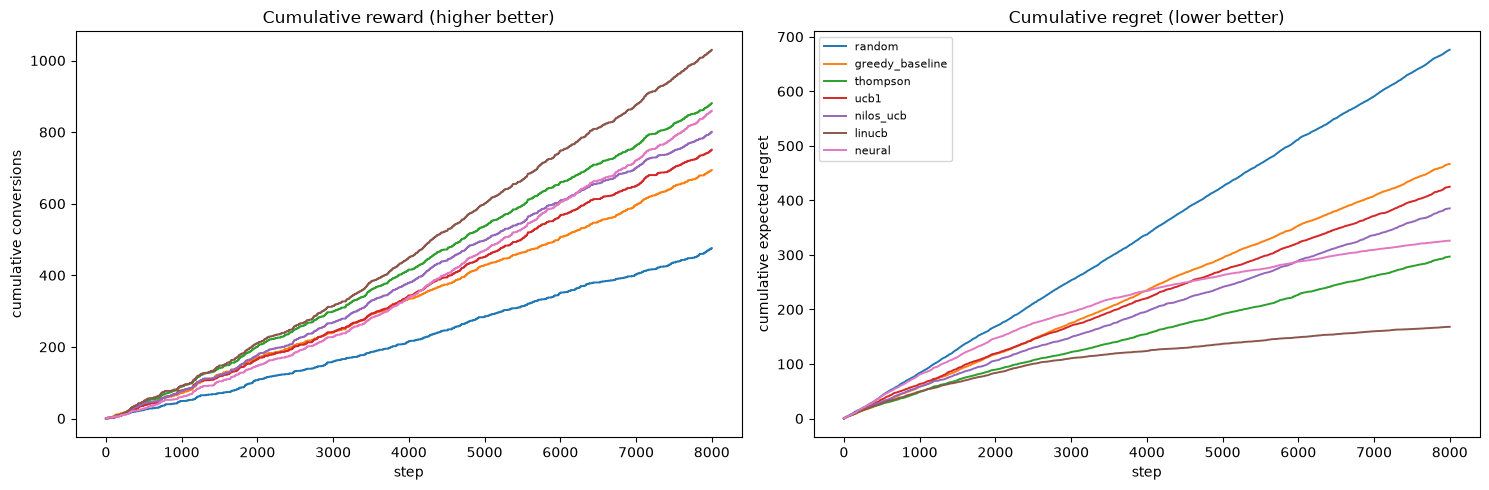

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, r in results.items():
    axes[0].plot(r.reward_curve, label=name, linewidth=1.4)
    axes[1].plot(r.regret_curve, label=name, linewidth=1.4)
axes[0].set_title('Cumulative reward (higher better)')
axes[0].set_xlabel('step'); axes[0].set_ylabel('cumulative conversions')
axes[1].set_title('Cumulative regret (lower better)')
axes[1].set_xlabel('step'); axes[1].set_ylabel('cumulative expected regret')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Final metrics and arm distribution

The deterministic baseline collapses onto a single arm (low entropy); the
contextual policies spread exposure according to context and reach the highest
share of optimal actions.

In [3]:
import pandas as pd
summary = pd.DataFrame({n: r.summary() for n, r in results.items()}).T
summary = summary[['conversion_rate', 'cum_regret', 'pct_optimal', 'exploration_entropy']]
summary.sort_values('cum_regret')

,conversion_rate,cum_regret,pct_optimal,exploration_entropy
linucb,0.128750,168.133592,0.563500,0.933255
thompson,0.110125,296.915158,0.417000,0.594378
neural,0.107500,326.156791,0.417000,0.906546
nilos_ucb,0.100125,385.306099,0.353875,0.894530
ucb1,0.093875,424.960892,0.321750,0.924362
greedy_baseline,0.086750,466.690051,0.271625,0.013846
random,0.059500,676.161250,0.136750,0.980915


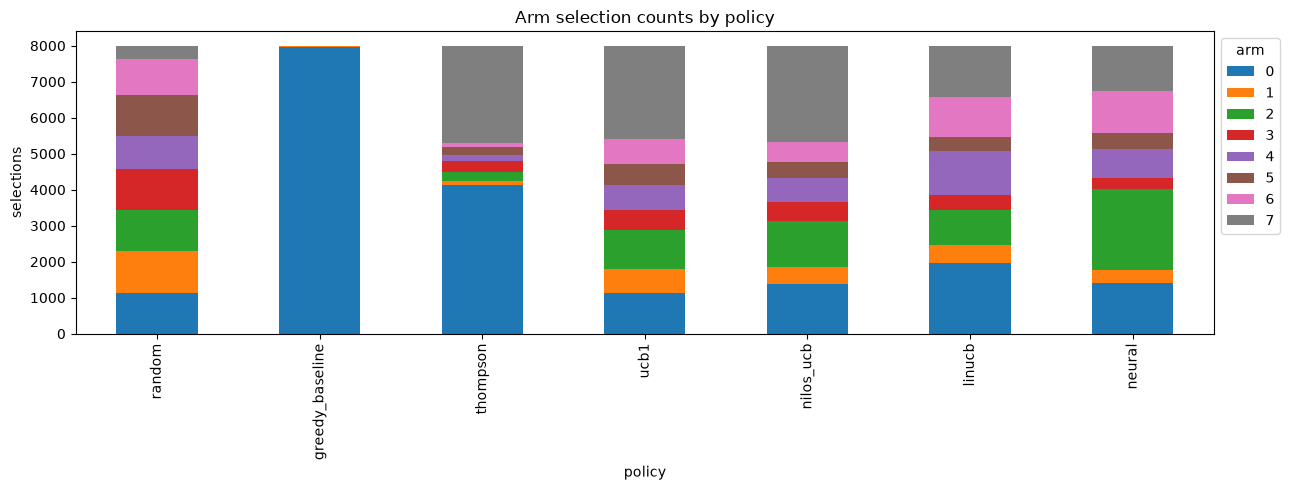

In [4]:
arm_dist = pd.DataFrame({n: r.arm_counts for n, r in results.items()}).T.fillna(0)
arm_dist.plot.bar(stacked=True, figsize=(13, 5), title='Arm selection counts by policy')
plt.xlabel('policy'); plt.ylabel('selections'); plt.legend(title='arm', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

## Takeaways

- **Contextual policies (LinUCB, neural) win**: lowest regret, highest conversion
  and share of optimal actions, because the best arm depends on the segment.
- **Thompson** is the strongest context-free policy; the **greedy baseline**
  exploits a single arm and plateaus.
- **Delayed feedback** penalizes pure exploitation: uncertainty-aware policies
  keep exploring while rewards are in flight.